# Machine Learning for Barbership Harmony - Data Clean-up & EDA

The data used in this project is spread across eight different CSVs. This notebook is used to consolidate the data into more usable datasets for future analysis. This notebook is also used for exploratory data analysis and to create basic visualizations of the data.

## Imports and file setup

In [1]:
# Imports

import numpy as np
import pandas as pd
import os
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect(':memory:')

In [2]:
# List the 8 CSV files
files = [
    'Chapter_Leaders.csv',
    'District_Leaders.csv',
    'Chapters_and_Choruses.csv',
    'Quartets_in_District.csv',
    'District_Members.csv',
    'District_Members_in_Chapters.csv',
    'District_Members_in_Choruses.csv',
    'District_Members_in_Quartets.csv'
]

In [3]:
# Process CSVs in bulk

for file in files:

    # Get the file name without the file extension
    file_name = os.path.splitext(file)[0]

    # Read the CSV into a temporary DataFrame
    df = pd.read_csv(file)

    # Standardize column headers with lowercase and underscores instead of spaces
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

    # Clean up specific columns
    for col in df.columns:
    
        # Convert all of the date columns from strings to dates
        if 'date' in col:
            df[col] = pd.to_datetime(df[col], errors='coerce')

        # Drop the rows where the chorus_end_date is null, since these are known to be data entry errors
        if 'chorus_end_date' in col:
            df = df.dropna(subset=[col])

    # Write to SQL
    table_name = f"{file_name}_table"
    df.to_sql(table_name, conn, index=False, if_exists='replace')

In [4]:
# Test that it worked
print(pd.read_sql_query("SELECT * FROM Quartets_in_District_table LIMIT 0", conn).columns.tolist())

['division', 'status', 'quartet_name', 'quartet_sc_id', 'start_date', 'end_date', 'city', 'state', 'classification']


## Compile data about Members

In [5]:
# Use SQL to compile data about Members
# Start with the members table, and add the number of current/former chapters, choruses, quartets, chapter leadership roles, and district leadership roles
# If a member left and rejoined a chapter, chorus, or quartet, only count it once and with the most recent status
# If a member left and restarted a district leadership role or chapter leadership role, only count it once and with the most recent status
# If a member left and rejoined the district, consider it a lapse in membership only if they were away for a year or more

member_query = '''
WITH lapse_calculation AS (
    SELECT
        member_number,
        (julianday(LEAD(district_join_date) OVER (PARTITION BY member_number ORDER BY district_join_date)) - julianday(district_end_date)) AS gap_days
    FROM district_members_table
),
lapse_stats AS (
    SELECT
        member_number,
        COUNT(CASE WHEN gap_days >=365 THEN 1 END) as significant_lapses
    FROM lapse_calculation
    GROUP BY member_number
)

SELECT 
    member.member_number,
    member.society_status,
    member.years_of_service,
    member.district_status,
    member.district_referral_count,
    member.gender,
    member.birthdate,
    member.district_original_join_date,
    member.district_most_recent_join_date,
    member.district_latest_end_date,
    member.district_tenure_days,

    COALESCE(chapter_table.current_chapter_count, 0) AS current_chapter_count,
    COALESCE(chapter_table.former_chapter_count, 0) AS former_chapter_count,

    COALESCE(chorus_table.current_chorus_count, 0) AS current_chorus_count,
    COALESCE(chorus_table.former_chorus_count, 0) AS former_chorus_count,

    COALESCE(quartet_table.current_quartet_count, 0) AS current_quartet_count,
    COALESCE(quartet_table.former_quartet_count, 0) AS former_quartet_count,

    COALESCE(chapter_leader_table.current_chapter_leader_count, 0) AS current_chapter_leader_count,
    COALESCE(chapter_leader_table.former_chapter_leader_count, 0) AS former_chapter_leader_count,

    COALESCE(district_leader_table.current_district_leader_count, 0) AS current_district_leader_count,
    COALESCE(district_leader_table.former_district_leader_count, 0) AS former_district_leader_count,

    COALESCE(lapse_stats.significant_lapses, 0) AS true_lapses

FROM (
    SELECT
        member_number,
        society_status,
        years_of_service,
        district_status,
        pon_count AS district_referral_count,
        gender,
        birthdate,
        MIN(district_join_date) AS district_original_join_date,
        MAX(district_join_date) AS district_most_recent_join_date,
        MAX(district_end_date) AS district_latest_end_date,
        SUM(CASE
            WHEN district_end_date IS NOT NULL AND district_end_date != ''
            THEN julianday(district_end_date) - julianday(district_join_date)
            ELSE julianday('now') - julianday(district_join_date)
        END) AS district_tenure_days

    FROM district_members_table
    GROUP BY member_number
) AS member

LEFT JOIN (
    SELECT 
        member_number,
        COUNT(CASE WHEN chapter_final_status = 1 THEN 1 END) AS current_chapter_count,
        COUNT(CASE WHEN chapter_final_status = 0 THEN 1 END) AS former_chapter_count
    FROM (
        SELECT
            member_number,
            chapter,
            MAX(CASE WHEN chapter_status = 'Current' THEN 1 ELSE 0 END) AS chapter_final_status
        FROM district_members_in_chapters_table
        GROUP BY member_number, chapter
    )
    GROUP BY member_number
) AS chapter_table ON member.member_number = chapter_table.member_number

LEFT JOIN (
    SELECT 
        member_number,
        COUNT(CASE WHEN chorus_final_status = 1 THEN 1 END) AS current_chorus_count,
        COUNT(CASE WHEN chorus_final_status = 0 THEN 1 END) AS former_chorus_count
    FROM (
        SELECT
            member_number,
            chorus,
            MAX(CASE WHEN chorus_status = 'Current' THEN 1 ELSE 0 END) as chorus_final_status
        FROM district_members_in_choruses_table
        GROUP BY member_number, chorus
    )
    GROUP BY member_number
) AS chorus_table ON member.member_number = chorus_table.member_number

LEFT JOIN (
    SELECT 
        member_number,
        COUNT(CASE WHEN quartet_final_status = 1 THEN 1 END) AS current_quartet_count,
        COUNT(CASE WHEN quartet_final_status = 0 THEN 1 END) AS former_quartet_count
    FROM (
        SELECT
            member_number,
            quartet_name,
            MAX(CASE WHEN status = 'Current' THEN 1 ELSE 0 END) as quartet_final_status
        FROM district_members_in_quartets_table
        GROUP BY member_number, quartet_name
    )
    GROUP BY member_number
) AS quartet_table ON member.member_number = quartet_table.member_number

LEFT JOIN (
    SELECT
        member_number,
        COUNT(CASE WHEN chapter_leader_final_status = 1 THEN 1 END) AS current_chapter_leader_count,
        COUNT(CASE WHEN chapter_leader_final_status = 0 THEN 1 END) AS former_chapter_leader_count
    FROM (
        SELECT
            member_number,
            role,
            MAX(CASE WHEN status = 'Current' THEN 1 ELSE 0 END) as chapter_leader_final_status
        FROM chapter_leaders_table
        GROUP BY member_number, role
    )
    GROUP BY member_number
) AS chapter_leader_table ON member.member_number = chapter_leader_table.member_number

LEFT JOIN (
    SELECT
        member_number,
        COUNT(CASE WHEN district_leader_final_status = 1 THEN 1 END) AS current_district_leader_count,
        COUNT(CASE WHEN district_leader_final_status = 0 THEN 1 END) AS former_district_leader_count
    FROM (
        SELECT
            member_number,
            officer_role,
            MAX(CASE WHEN status = 'Current' THEN 1 ELSE 0 END) as district_leader_final_status
        FROM district_leaders_table
        GROUP BY member_number, officer_role
    )
    GROUP BY member_number
) AS district_leader_table ON member.member_number = district_leader_table.member_number

LEFT JOIN 
    lapse_stats ON member.member_number = lapse_stats.member_number


;'''

member_stats = pd.read_sql_query(member_query, conn)

In [6]:
# Psuedo-anonymize the data to remove member number

# Identify unique member numbers
unique_member_numbers = member_stats['member_number'].unique()

# Shuffle the member numbers randomly
np.random.shuffle(unique_member_numbers)

# Map member numbers to a fake ID number
id_mapping = {member_number: f'Num_{i}' for i, member_number in enumerate(unique_member_numbers)}

# Save the mapping key locally to allow for mapping fake ID numbers back to actual member numbers
key_mapping = pd.DataFrame(list(id_mapping.items()), columns=['real_member_number', 'fake_member_number'])
key_mapping.to_csv('private_member_number_mapping.csv', index=False)

# Overwrite the real member numbers with the fake ones
member_stats['member_number'] = member_stats['member_number'].map(id_mapping)

member_stats.head()

,member_number,society_status,years_of_service,district_status,district_referral_count,gender,birthdate,district_original_join_date,district_most_recent_join_date,district_latest_end_date,...,former_chapter_count,current_chorus_count,former_chorus_count,current_quartet_count,former_quartet_count,current_chapter_leader_count,former_chapter_leader_count,current_district_leader_count,former_district_leader_count,true_lapses
0,Num_5084,Expired,8,Former,0,Male,1971-01-01 00:00:00,2008-04-22 00:00:00,2015-01-10 00:00:00,2020-01-09 00:00:00,...,2,0,1,0,2,0,0,0,0,1
1,Num_4577,Expired,6,Former,0,Male,1953-09-20 00:00:00,2009-01-22 00:00:00,2009-01-22 00:00:00,2013-10-02 00:00:00,...,1,0,1,0,1,0,0,0,0,0
2,Num_2065,Expired,2,Former,0,Male,1945-02-28 00:00:00,2008-08-26 00:00:00,2008-08-26 00:00:00,2011-02-25 00:00:00,...,1,0,1,0,0,0,0,0,0,0
3,Num_3195,Expired,12,Former,0,Male,1937-06-20 00:00:00,2000-01-01 00:00:00,2000-01-01 00:00:00,2011-12-31 00:00:00,...,2,0,2,0,0,0,1,0,0,0
4,Num_4481,Expired,7,Former,0,Male,1942-02-16 00:00:00,2009-02-13 00:00:00,2009-02-13 00:00:00,2016-02-12 00:00:00,...,1,0,1,0,0,0,0,0,0,0


In [7]:
# Save back to SQL to be able to use again
member_stats.to_sql('member_table', conn, if_exists='replace', index=False)

7387

In [8]:
# Check the data information
member_stats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7387 entries, 0 to 7386
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   member_number                   7387 non-null   object 
 1   society_status                  7387 non-null   object 
 2   years_of_service                7387 non-null   int64  
 3   district_status                 7386 non-null   object 
 4   district_referral_count         7387 non-null   int64  
 5   gender                          7371 non-null   object 
 6   birthdate                       7387 non-null   object 
 7   district_original_join_date     7387 non-null   object 
 8   district_most_recent_join_date  7387 non-null   object 
 9   district_latest_end_date        7386 non-null   object 
 10  district_tenure_days            7387 non-null   float64
 11  current_chapter_count           7387 non-null   int64  
 12  former_chapter_count            73

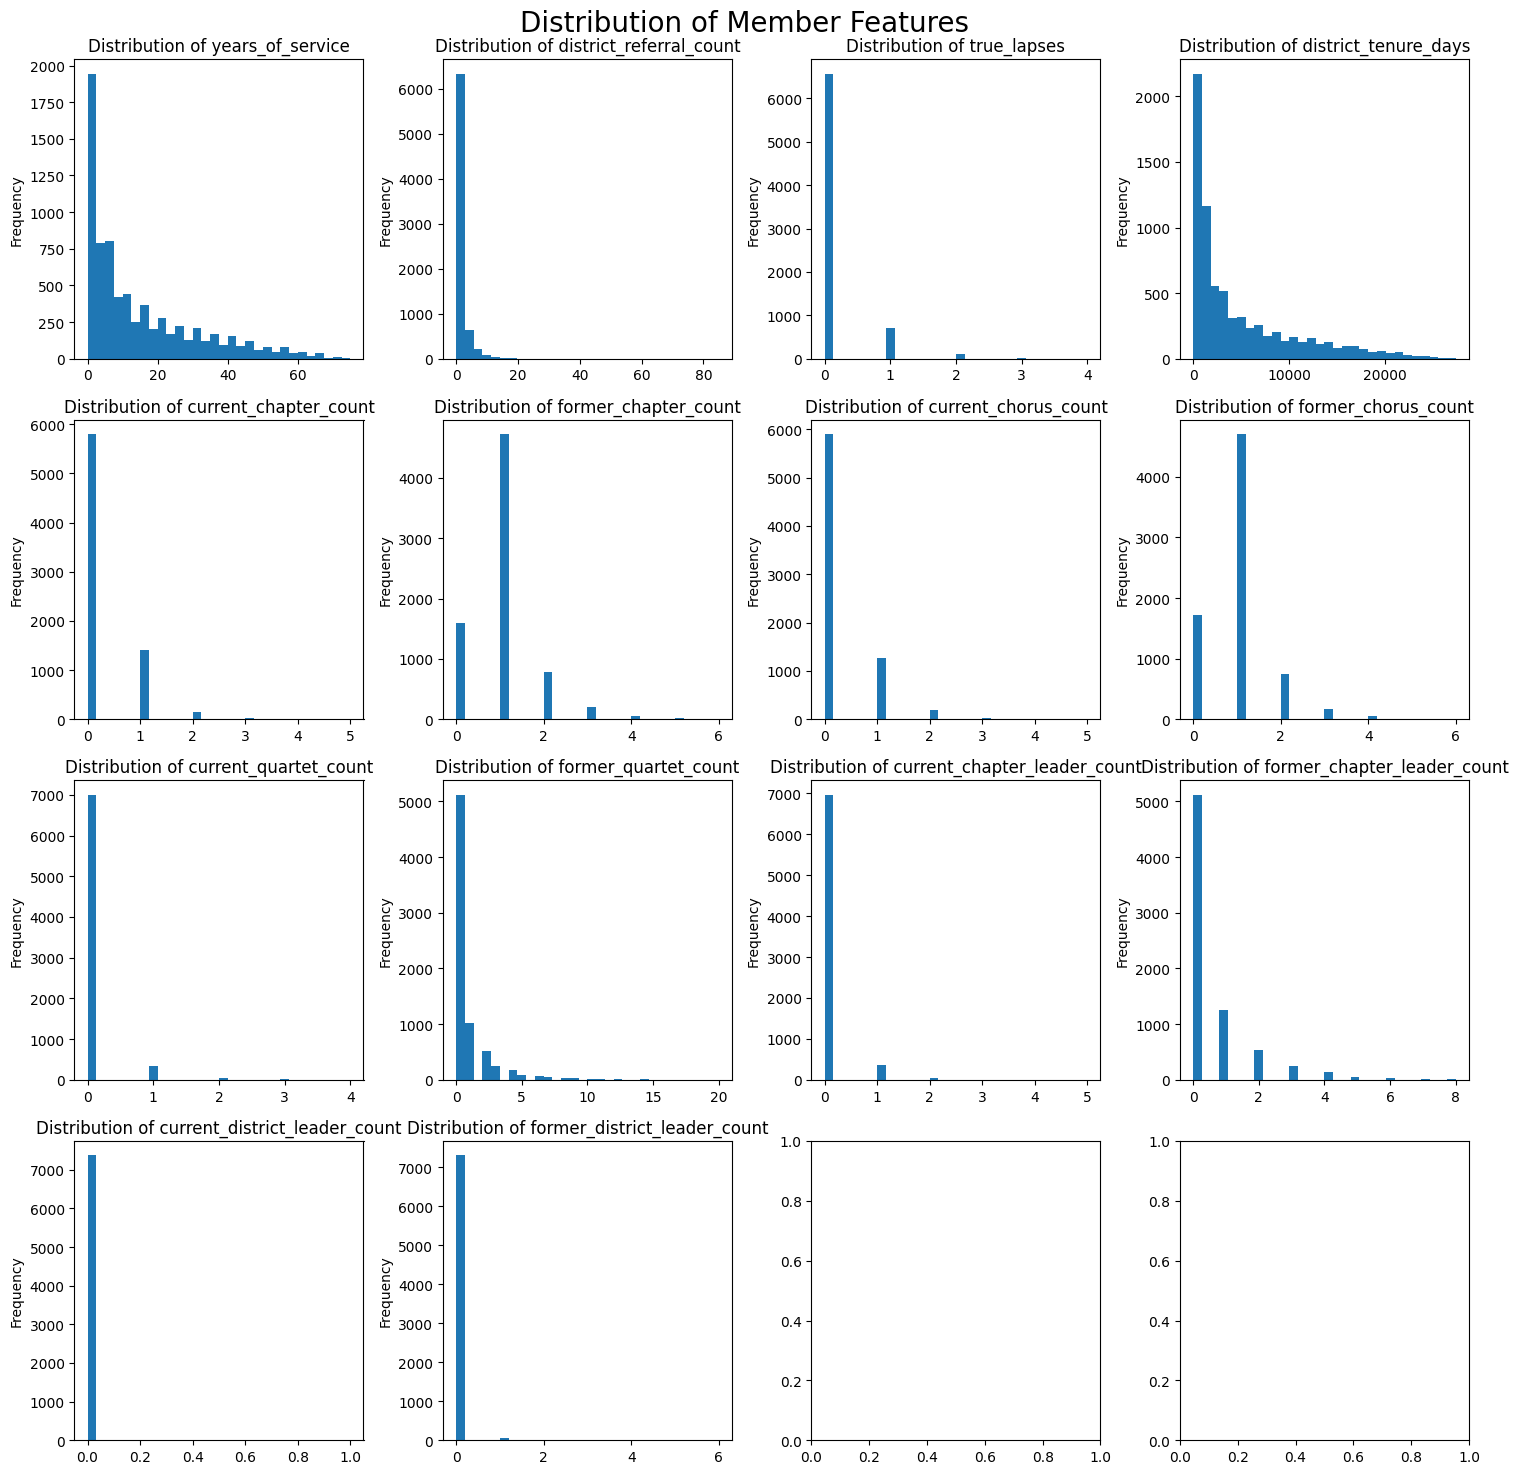

In [9]:
# Plot the numerical columns as histograms to make sure they make sense
histogram_columns_members = [
    'years_of_service',
    'district_referral_count',
    'true_lapses',
    'district_tenure_days',
    'current_chapter_count',
    'former_chapter_count',
    'current_chorus_count',
    'former_chorus_count',
    'current_quartet_count',
    'former_quartet_count',
    'current_chapter_leader_count',
    'former_chapter_leader_count',
    'current_district_leader_count',
    'former_district_leader_count'
]

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(15,15))
axe = axes.ravel()
for i, col in enumerate(histogram_columns_members):
    member_stats[col].plot(kind='hist', bins=30, ax=axe[i])
    axe[i].set_title(f'Distribution of {col}')
    axe[i].set_xlabel('')

plt.suptitle('Distribution of Member Features', size=20)
plt.tight_layout()
plt.show()

In [10]:
# Write cleaned-up DataFrame to CSV for use in modeling

member_stats.to_csv('member_data_compiled.csv', index=False)

## Compile data about Choruses

In [11]:
# Use SQL to compile data about Choruses
# Start with the chapters and choruses table, filter to just choruses that are still active, and add the average age of members and average years of service
# Exclude members with a chorus_end_date of null since these are data entry errors
# Get snapshots of the number of active members and average age for each year from 2022 to 2026

chorus_query = '''
SELECT
    cc_table.chorus_sc_code,
    cc_table.status,
    cc_table.established_date,
    cc_table.city,
    cc_table.state,
    cc_table.chorus_member_count,

    snapshot_2026.active_members_2026,
    snapshot_2025.active_members_2025,
    snapshot_2024.active_members_2024,
    snapshot_2023.active_members_2023,
    snapshot_2022.active_members_2022,

    (CAST(snapshot_2024.active_members_2024 AS FLOAT) / snapshot_2022.active_members_2022) - 1 AS two_year_growth_rate_2024,
    (CAST(snapshot_2026.active_members_2026 AS FLOAT) / snapshot_2024.active_members_2024) - 1 AS two_year_growth_rate_2026,

    snapshot_2026.avg_age_2026,
    snapshot_2025.avg_age_2025,
    snapshot_2024.avg_age_2024,
    snapshot_2023.avg_age_2023,
    snapshot_2022.avg_age_2022,

    (snapshot_2024.avg_age_2024 - snapshot_2022.avg_age_2022) AS two_year_age_change_2024,
    (snapshot_2026.avg_age_2026 - snapshot_2024.avg_age_2024) AS two_year_age_change_2026,

    snapshot_2024_rates.single_quartet_rate_2024,
    snapshot_2024_rates.multi_quartet_rate_2024,
    snapshot_2024_rates.chapter_leader_density_2024,
    snapshot_2024_rates.former_chapter_leader_density_2024,
    snapshot_2024_rates.district_leader_density_2024,
    snapshot_2024_rates.former_district_leader_density_2024,

    snapshot_2026_rates.single_quartet_rate_2026,
    snapshot_2026_rates.multi_quartet_rate_2026,
    snapshot_2026_rates.chapter_leader_density_2026,
    snapshot_2026_rates.former_chapter_leader_density_2026,
    snapshot_2026_rates.district_leader_density_2026,
    snapshot_2026_rates.former_district_leader_density_2026

FROM chapters_and_choruses_table AS cc_table

LEFT JOIN (
    SELECT
        chorus,
        AVG(age) AS avg_member_age,
        AVG(years_of_service) AS avg_years_in_chorus
    FROM (
        SELECT
            member_number,
            chorus,
            chorus_status,
            CAST((julianday('2025-01-01') - julianday(birthdate)) / 365.25 AS INTEGER) AS age,
            CAST((julianday('2025-01-01') - julianday(chorus_join_date)) / 365.25 AS INTEGER) AS years_in_chorus,
            years_of_service
        FROM district_members_in_choruses_table
        GROUP BY member_number, chorus
    )
    WHERE chorus_status = 'Current'
    GROUP BY chorus
) AS age_data ON cc_table.chorus = age_data.chorus

LEFT JOIN (
    SELECT
        chorus,
        COUNT(member_number) AS active_members_2026,
        AVG(2026 - strftime('%Y', birthdate)) AS avg_age_2026
    FROM district_members_in_choruses_table
    WHERE chorus_join_date <= '2026-01-01'
        AND chorus_end_date > '2026-01-01'
    GROUP BY chorus
) AS snapshot_2026 ON cc_table.chorus = snapshot_2026.chorus

LEFT JOIN (
    SELECT
        chorus,
        COUNT(member_number) AS active_members_2025,
        AVG(2025 - strftime('%Y', birthdate)) AS avg_age_2025
    FROM district_members_in_choruses_table
    WHERE chorus_join_date <= '2025-01-01'
        AND chorus_end_date > '2025-01-01'
    GROUP BY chorus
) AS snapshot_2025 ON cc_table.chorus = snapshot_2025.chorus

LEFT JOIN (
    SELECT
        chorus,
        COUNT(member_number) AS active_members_2024,
        AVG(2024 - strftime('%Y', birthdate)) AS avg_age_2024
    FROM district_members_in_choruses_table
    WHERE chorus_join_date <= '2024-01-01'
        AND chorus_end_date > '2024-01-01'
    GROUP BY chorus
) AS snapshot_2024 ON cc_table.chorus = snapshot_2024.chorus

LEFT JOIN (
    SELECT
        chorus,
        COUNT(member_number) AS active_members_2023,
        AVG(2023 - strftime('%Y', birthdate)) AS avg_age_2023
    FROM district_members_in_choruses_table
    WHERE chorus_join_date <= '2023-01-01'
        AND chorus_end_date > '2023-01-01'
    GROUP BY chorus
) AS snapshot_2023 ON cc_table.chorus = snapshot_2023.chorus

LEFT JOIN (
    SELECT
        chorus,
        COUNT(member_number) AS active_members_2022,
        AVG(2022 - strftime('%Y', birthdate)) AS avg_age_2022
    FROM district_members_in_choruses_table
    WHERE chorus_join_date <= '2022-01-01'
        AND chorus_end_date > '2022-01-01'
    GROUP BY chorus
) AS snapshot_2022 ON cc_table.chorus = snapshot_2022.chorus

LEFT JOIN (
    SELECT
        mc.chorus,
        
        CAST(COUNT(CASE WHEN q.total_quartets = 1 THEN 1 END) AS FLOAT) / COUNT(mc.member_number) AS single_quartet_rate_2024,
        CAST(COUNT(CASE WHEN q.total_quartets > 1 THEN 1 END) AS FLOAT) / COUNT(mc.member_number) AS multi_quartet_rate_2024,
        
        CAST(COUNT(CASE WHEN cl.is_chapter_leader = 1 THEN 1 END) AS FLOAT) / COUNT(mc.member_number) AS chapter_leader_density_2024,
        CAST(COUNT(CASE WHEN cl.was_chapter_leader = 1 THEN 1 END) AS FLOAT) / COUNT(mc.member_number) AS former_chapter_leader_density_2024,
        
        CAST(COUNT(CASE WHEN dl.is_district_leader = 1 THEN 1 END) AS FLOAT) / COUNT(mc.member_number) AS district_leader_density_2024,
        CAST(COUNT(CASE WHEN dl.was_district_leader = 1 THEN 1 END) AS FLOAT) / COUNT(mc.member_number) AS former_district_leader_density_2024
    
    FROM district_members_in_choruses_table AS mc
    
    LEFT JOIN (
        SELECT
            member_number,
            COUNT(DISTINCT quartet_name) AS total_quartets
        FROM district_members_in_quartets_table
        GROUP BY member_number
    ) AS q ON mc.member_number = q.member_number
    
    LEFT JOIN (
        SELECT
            member_number,
            MAX(CASE WHEN status='Current' THEN 1 ELSE 0 END) AS is_chapter_leader,
            MAX(CASE WHEN status='Former' THEN 1 ELSE 0 END) as was_chapter_leader
        FROM chapter_leaders_table
        GROUP BY member_number
    ) AS cl ON mc.member_number = cl.member_number
    
    LEFT JOIN(
        SELECT
            member_number,
            MAX(CASE WHEN status='Current' THEN 1 ELSE 0 END) AS is_district_leader,
            MAX(CASE WHEN status='Former' THEN 1 ELSE 0 END) AS was_district_leader
        FROM district_leaders_table
        GROUP BY member_number
    ) AS dl ON mc.member_number = dl.member_number
    
    WHERE mc.chorus_join_date <= '2024-01-01'
        AND mc.chorus_end_date > '2024-01-01'
    GROUP BY mc.chorus
) AS snapshot_2024_rates ON cc_table.chorus = snapshot_2024_rates.chorus

LEFT JOIN (
    SELECT
        mc.chorus,
        
        CAST(COUNT(CASE WHEN q.total_quartets = 1 THEN 1 END) AS FLOAT) / COUNT(mc.member_number) AS single_quartet_rate_2026,
        CAST(COUNT(CASE WHEN q.total_quartets > 1 THEN 1 END) AS FLOAT) / COUNT(mc.member_number) AS multi_quartet_rate_2026,
        
        CAST(COUNT(CASE WHEN cl.is_chapter_leader = 1 THEN 1 END) AS FLOAT) / COUNT(mc.member_number) AS chapter_leader_density_2026,
        CAST(COUNT(CASE WHEN cl.was_chapter_leader = 1 THEN 1 END) AS FLOAT) / COUNT(mc.member_number) AS former_chapter_leader_density_2026,
        
        CAST(COUNT(CASE WHEN dl.is_district_leader = 1 THEN 1 END) AS FLOAT) / COUNT(mc.member_number) AS district_leader_density_2026,
        CAST(COUNT(CASE WHEN dl.was_district_leader = 1 THEN 1 END) AS FLOAT) / COUNT(mc.member_number) AS former_district_leader_density_2026
    
    FROM district_members_in_choruses_table AS mc
    
    LEFT JOIN (
        SELECT
            member_number,
            COUNT(DISTINCT quartet_name) AS total_quartets
        FROM district_members_in_quartets_table
        GROUP BY member_number
    ) AS q ON mc.member_number = q.member_number
    
    LEFT JOIN (
        SELECT
            member_number,
            MAX(CASE WHEN status='Current' THEN 1 ELSE 0 END) AS is_chapter_leader,
            MAX(CASE WHEN status='Former' THEN 1 ELSE 0 END) as was_chapter_leader
        FROM chapter_leaders_table
        GROUP BY member_number
    ) AS cl ON mc.member_number = cl.member_number
    
    LEFT JOIN(
        SELECT
            member_number,
            MAX(CASE WHEN status='Current' THEN 1 ELSE 0 END) AS is_district_leader,
            MAX(CASE WHEN status='Former' THEN 1 ELSE 0 END) AS was_district_leader
        FROM district_leaders_table
        GROUP BY member_number
    ) AS dl ON mc.member_number = dl.member_number
    
    WHERE mc.chorus_join_date <= '2026-01-01'
        AND mc.chorus_end_date > '2026-01-01'
    GROUP BY mc.chorus
) AS snapshot_2026_rates ON cc_table.chorus = snapshot_2026_rates.chorus


WHERE cc_table.status = 'Active'
GROUP BY cc_table.chorus

'''

# Save as a DataFrame
chorus_stats = pd.read_sql_query(chorus_query, conn)
chorus_stats.head(10)

,chorus_sc_code,status,established_date,city,state,chorus_member_count,active_members_2026,active_members_2025,active_members_2024,active_members_2023,...,chapter_leader_density_2024,former_chapter_leader_density_2024,district_leader_density_2024,former_district_leader_density_2024,single_quartet_rate_2026,multi_quartet_rate_2026,chapter_leader_density_2026,former_chapter_leader_density_2026,district_leader_density_2026,former_district_leader_density_2026
0,J047A,Active,1948-06-14 00:00:00,Alexandria,Virginia,152,154.0,152.0,158.0,161.0,...,0.094937,0.474684,0.018987,0.088608,0.181818,0.448052,0.110390,0.422078,0.019481,0.077922
1,J033B,Active,1979-08-03 00:00:00,Cumberland,Maryland,3,3.0,3.0,3.0,2.0,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
2,None,Active,1984-11-26 00:00:00,Flemington,New Jersey,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,J113A,Active,1996-01-09 00:00:00,Easton,Maryland,2,2.0,9.0,4.0,6.0,...,0.000000,0.750000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
4,J065A,Active,1979-01-31 00:00:00,Bel Air,Maryland,8,7.0,9.0,12.0,13.0,...,0.250000,0.666667,0.000000,0.000000,0.000000,0.285714,0.285714,0.571429,0.000000,0.000000
5,J019A,Active,1945-06-22 00:00:00,Teaneck,New Jersey,15,16.0,18.0,20.0,20.0,...,0.350000,0.650000,0.000000,0.000000,0.062500,0.000000,0.437500,0.687500,0.000000,0.000000
6,J104A,Active,1984-12-04 00:00:00,Warrenton,Virginia,12,11.0,14.0,16.0,9.0,...,0.312500,0.500000,0.000000,0.000000,0.272727,0.181818,0.454545,0.636364,0.000000,0.000000
7,J110A,Active,1994-06-10 00:00:00,Bedford,Virginia,15,14.0,17.0,17.0,16.0,...,0.000000,0.823529,0.000000,0.000000,0.285714,0.214286,0.000000,0.928571,0.000000,0.000000
8,J063A,Active,1956-03-30 00:00:00,Galloway,New Jersey,3,4.0,6.0,6.0,7.0,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
9,J095A,Active,1962-02-21 00:00:00,Philadelphia,Pennsylvania,4,5.0,9.0,8.0,8.0,...,0.500000,1.000000,0.000000,0.000000,0.000000,0.000000,0.400000,0.800000,0.000000,0.000000


In [12]:
# Save back to SQL to be able to use again
chorus_stats.to_sql('chorus_table', conn, if_exists='replace', index=False)

80

In [13]:
chorus_stats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 32 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   chorus_sc_code                       79 non-null     object 
 1   status                               80 non-null     object 
 2   established_date                     80 non-null     object 
 3   city                                 80 non-null     object 
 4   state                                80 non-null     object 
 5   chorus_member_count                  80 non-null     int64  
 6   active_members_2026                  75 non-null     float64
 7   active_members_2025                  74 non-null     float64
 8   active_members_2024                  74 non-null     float64
 9   active_members_2023                  73 non-null     float64
 10  active_members_2022                  73 non-null     float64
 11  two_year_growth_rate_2024         

In [14]:
# Write cleaned-up DataFrame to CSV for use in modeling

chorus_stats.to_csv('chorus_data_compiled.csv', index=False)

# Exploratory Data Analysis

## Chorus Data Visualizations

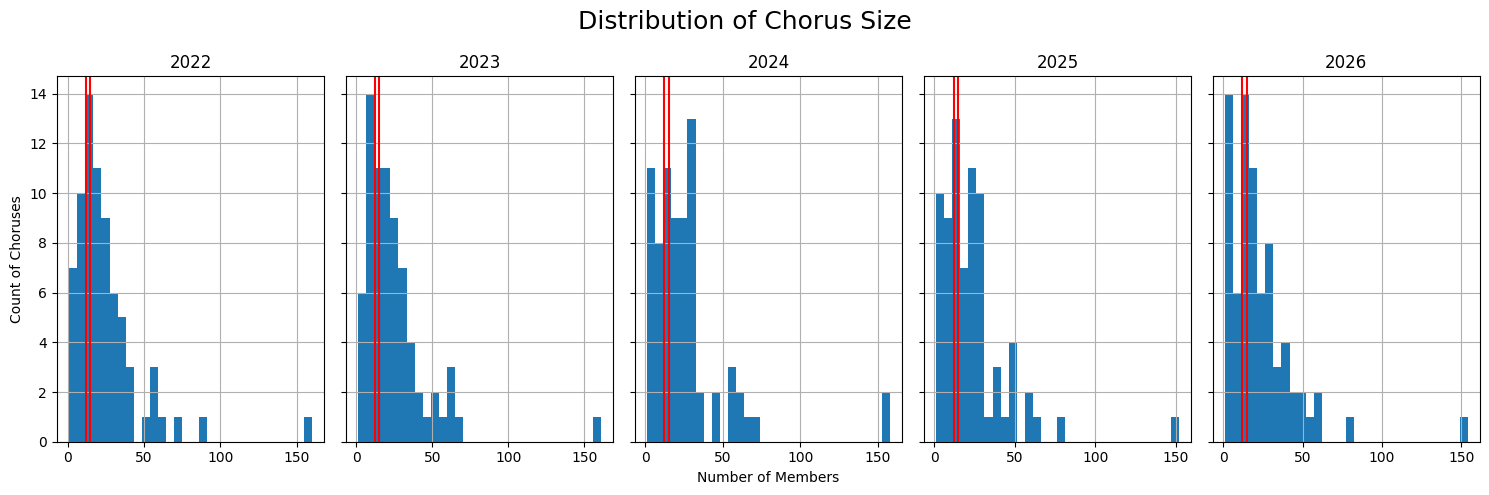

In [15]:
# Plot visualizations of active member count for each snapshot year

# Set the number of bins to use
bins=30

# Put the years in a list to use in a for loop
years = [2022, 2023, 2024, 2025, 2026]

# Create the subplots
fig, axes = plt.subplots(1, 5, figsize=(15, 5), sharey=True)

# Create the plots through a loop
for i, year in enumerate(years):
    col = f'active_members_{year}'

    # Plot the histogram
    chorus_stats[col].hist(bins=bins, ax=axes[i])

    # Add two vertical lines at 12 and 15 to show the "danger zone" of chorus size
    axes[i].axvline(12, color='red')
    axes[i].axvline(15, color='red')

    # Set the title
    axes[i].set_title(str(year))

# Set a single x-label aligned with the middle subplot
axes[2].set_xlabel('Number of Members')

# Set the y-label aligned with the left-most subplot
axes[0].set_ylabel('Count of Choruses')

plt.suptitle('Distribution of Chorus Size', fontsize=18)
plt.tight_layout()
plt.show()

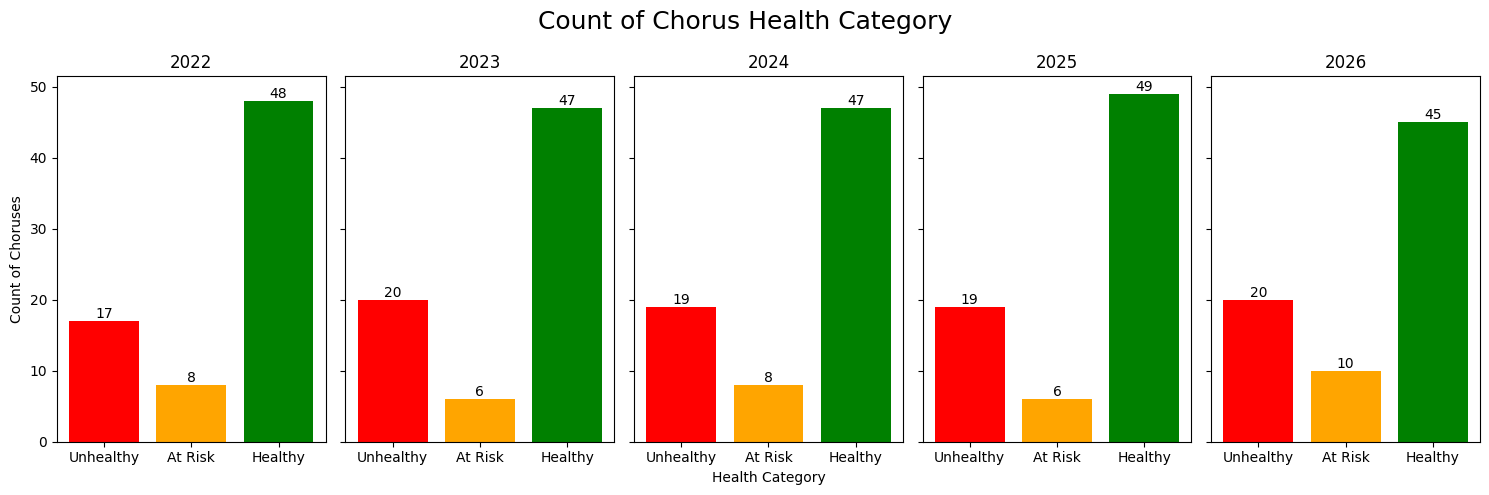

In [16]:
# Plot the number of courses that are already unhealthy (<12) vs. at-risk (12-15) vs. healthy (15+) based on member count for each year

# Create the subplots
fig, axes = plt.subplots(1, 5, figsize=(15, 5), sharey=True)

# Initialize the lists of counts
unhealthy = []
at_risk = []
healthy = []

# Create the plots through a loop
for i, year in enumerate(years):
    col = f'active_members_{year}'

    # Count how many choruses are in each category
    unhealthy.append(len(chorus_stats[chorus_stats[col] < 12]))
    at_risk.append(len(chorus_stats[(chorus_stats[col] >= 12) & (chorus_stats[col] <15)]))
    healthy.append(len(chorus_stats[chorus_stats[col] >=15]))

    # Plot the bar charts with value labels
    axes[i].bar_label(axes[i].bar(['Unhealthy', 'At Risk', 'Healthy'], [unhealthy[i], at_risk[i], healthy[i]], color=['red', 'orange', 'green']))

    # Set the title
    axes[i].set_title(str(year))


# Set a single x-label aligned with the middle subplot
axes[2].set_xlabel('Health Category')

# Set the y-label aligned with the left-most subplot
axes[0].set_ylabel('Count of Choruses')

plt.suptitle('Count of Chorus Health Category', fontsize=18)
plt.tight_layout()
plt.show()


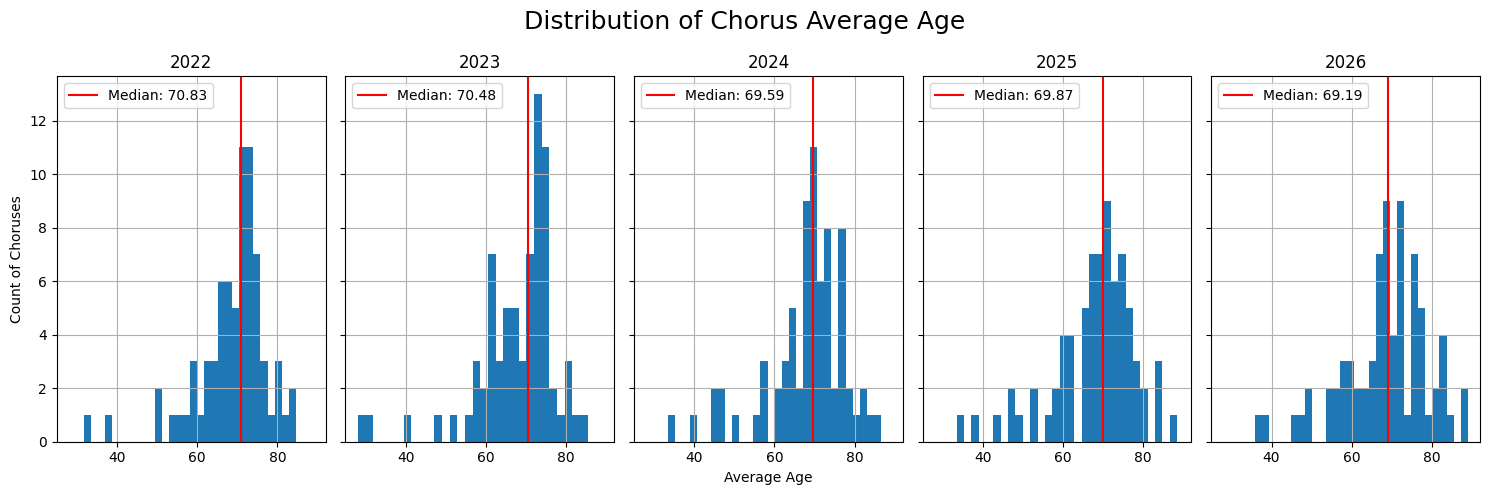

In [17]:
# Plot visualizations of average age for each snapshot year

# Set the number of bins to use
bins=30

# Put the years in a list to use in a for loop
years = [2022, 2023, 2024, 2025, 2026]

# Create the subplots
fig, axes = plt.subplots(1, 5, figsize=(15, 5), sharey=True, sharex=True)

# Create the plots through a loop
for i, year in enumerate(years):
    col = f'avg_age_{year}'

    # Plot the histogram
    chorus_stats[col].hist(bins=bins, ax=axes[i])

    # Add a vertical lines for the median
    axes[i].axvline(chorus_stats[col].median(), color='red', label=f'Median: {chorus_stats[col].median():.2f}')

    # Set the title
    axes[i].set_title(str(year))

    axes[i].legend()

# Set a single x-label aligned with the middle subplot
axes[2].set_xlabel('Average Age')

# Set the y-label aligned with the left-most subplot
axes[0].set_ylabel('Count of Choruses')

plt.suptitle('Distribution of Chorus Average Age', fontsize=18)
plt.tight_layout()
plt.show()

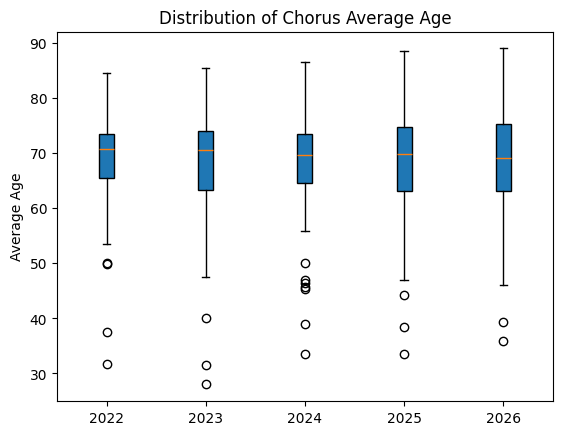

In [18]:
# Plot visualizations of average age for each snapshot year
fig, ax = plt.subplots()

# Create the plots through a loop
for i, year in enumerate(years):
    col = f'avg_age_{year}'

    # Plot the box plot
    ax.boxplot(chorus_stats[col].dropna(), positions=[i+1], patch_artist=True)

ax.set_xticks(range(1, len(years) +1))
ax.set_xticklabels(years)

plt.title('Distribution of Chorus Average Age')
plt.ylabel('Average Age')
plt.show()